# Words Frequency

In [3]:
import sys, os
sys.path.append(os.path.abspath("src"))
from src.utils.utils_import import *
from src.utils.evaluation_utils import *

c:\EPFL_programmation\anaconda3\envs\ada\Lib\site-packages\sentence_transformers\cross_encoder\CrossEncoder.py:13: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


In [ ]:
# NLTK setup (robust)
import nltk
from nltk.corpus import stopwords
try:
    from nltk.tokenize import word_tokenize
except Exception:
    word_tokenize = None

def _ensure_nltk():
    # Try exact resources required by recent NLTK
    for pkg in ["stopwords", "punkt", "punkt_tab"]:
        try:
            nltk.data.find(f"corpora/{pkg}") if pkg=="stopwords" else nltk.data.find(f"tokenizers/{pkg}")
        except LookupError:
            nltk.download(pkg, quiet=True)

_ensure_nltk()

# After ensuring, import again (in case it failed earlier)
from nltk.corpus import stopwords
try:
    from nltk.tokenize import word_tokenize as _wt
    word_tokenize = _wt
except Exception:
    pass

EN_STOP = set(stopwords.words('english'))

# ---- config ----
PATH = pathlib.Path("data/newyorker_caption_contest/contests.json")
FIELDS = ["image_descriptions", "image_uncanny_descriptions", "image_locations", "questions"]
OUTDIR = pathlib.Path("data/GoogleTrends/frequent_words")

# Fallback regex tokenizer (letters only, >=3 chars)
TOKEN_RE = re.compile(r"[A-Za-z]{3,}")

def load_records(path: pathlib.Path):
    txt = path.read_text(encoding="utf-8")
    try:
        obj = json.loads(txt)
    except json.JSONDecodeError:
        recs = []
        with path.open(encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if line:
                    recs.append(json.loads(line))
        return recs
    if isinstance(obj, list):
        return obj
    if isinstance(obj, dict):
        if "contests" in obj and isinstance(obj["contests"], list):
            return obj["contests"]
        return [obj]
    raise ValueError("Unsupported JSON structure")

def collect_texts(records, field):
    out = []
    for r in records:
        m = r.get("metadata") or {}
        v = m.get(field) if isinstance(m, dict) else None
        if isinstance(v, list):
            out.extend([s for s in v if isinstance(s, str)])
        elif isinstance(v, str):
            out.append(v)
    return out

def tokenize_lower(text: str):
    """Prefer NLTK word_tokenize; fallback to regex if unavailable."""
    if word_tokenize is not None:
        try:
            return [w.lower() for w in word_tokenize(text)]
        except LookupError:
            # If punkt/punkt_tab still missing for some reason, fallback
            return [w.lower() for w in TOKEN_RE.findall(text)]
    else:
        return [w.lower() for w in TOKEN_RE.findall(text)]

def count_tokens_nltk(texts):
    c = Counter()
    for t in texts:
        tokens = tokenize_lower(t)
        # keep only alphabetic tokens, >=3 chars, not in stopwords
        filtered = [w for w in tokens if w.isalpha() and len(w) >= 3 and w not in EN_STOP]
        c.update(filtered)
    return c

def save_counts_csv(counter: Counter, out_path: pathlib.Path):
    out_path.parent.mkdir(parents=True, exist_ok=True)
    with out_path.open("w", newline="", encoding="utf-8") as f:
        w = csv.writer(f)
        w.writerow(["token", "count"])
        for tok, freq in sorted(counter.items(), key=lambda kv: (-kv[1], kv[0])):
            w.writerow([tok, freq])

# ---- run ----
records = load_records(PATH)

for field in FIELDS:
    texts = collect_texts(records, field)
    counts = count_tokens_nltk(texts)
    outfile = OUTDIR / f"{field}__unigrams_nltk.csv"
    save_counts_csv(counts, outfile)


## Visualize the frequency

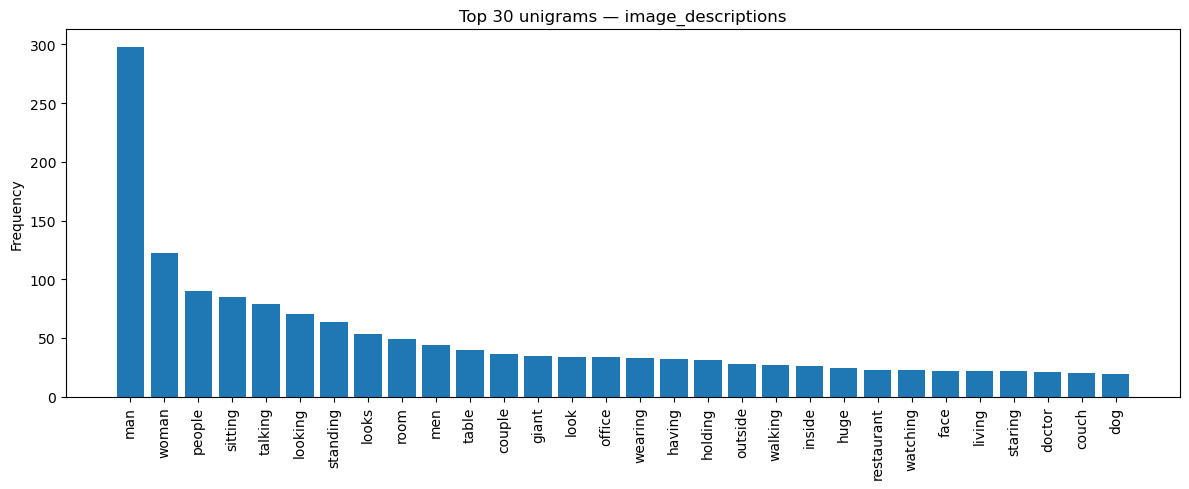

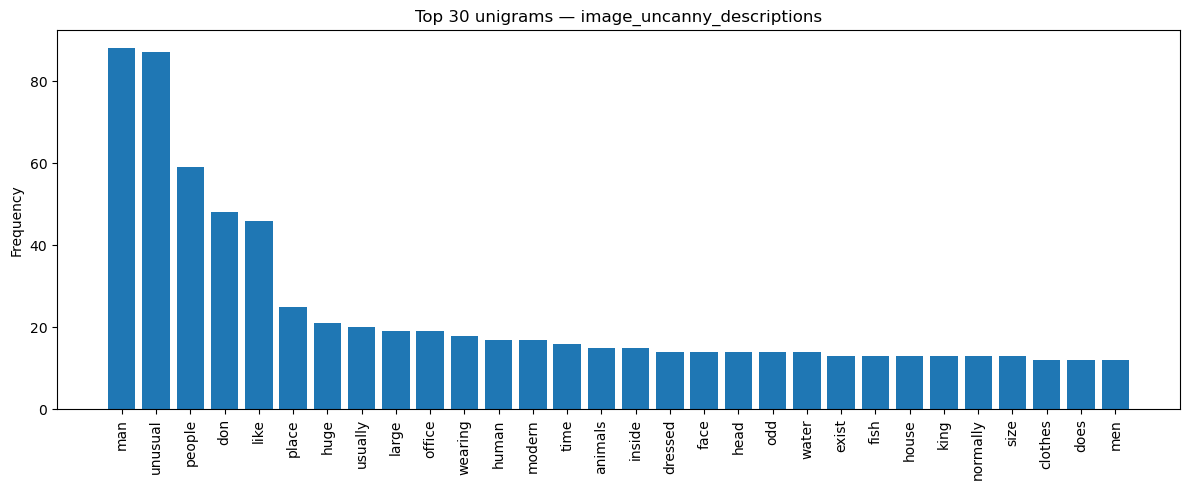

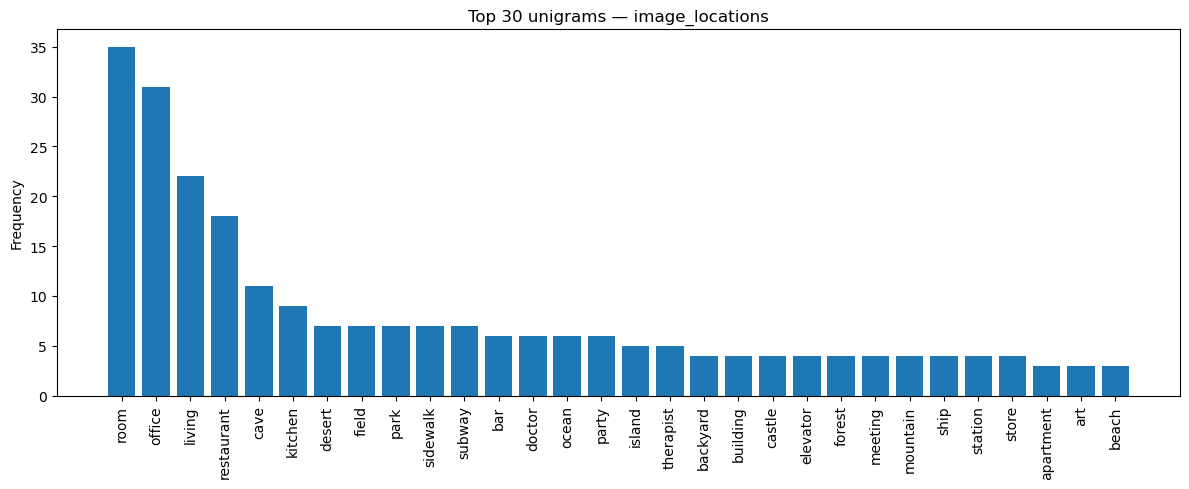

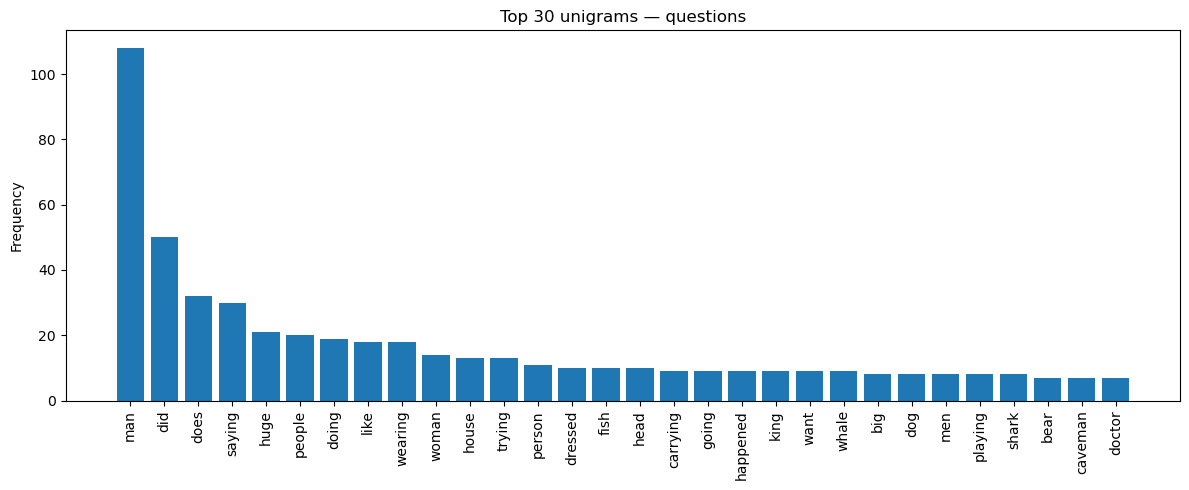

In [82]:
def load_records(path: pathlib.Path):
    txt = path.read_text(encoding="utf-8")
    try:
        obj = json.loads(txt)
    except json.JSONDecodeError:
        # JSONL fallback
        recs = []
        with path.open(encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if line:
                    recs.append(json.loads(line))
        return recs
    if isinstance(obj, list):
        return obj
    if isinstance(obj, dict):
        if "contests" in obj and isinstance(obj["contests"], list):
            return obj["contests"]
        return [obj]
    raise ValueError("Unsupported JSON structure")

def collect_texts(records, field: str) -> List[str]:
    out = []
    for r in records:
        m = r.get("metadata") or {}
        v = m.get(field) if isinstance(m, dict) else None
        if isinstance(v, list):
            out.extend([s for s in v if isinstance(s, str)])
        elif isinstance(v, str):
            out.append(v)
    return out

# --- Run per field ---
records = load_records(PATH)

for field in FIELDS:
    texts = collect_texts(records, field)
    if not texts:
        print(f"[{field}] No texts found, skipping.")
        continue

    vectorizer = CountVectorizer(
        stop_words="english",
        token_pattern=r"(?u)\b[a-zA-Z]{3,}\b",
        ngram_range=NGRAM_RANGE
    )
    X = vectorizer.fit_transform(texts)               # sparse [n_docs, n_vocab]
    counts = np.asarray(X.sum(axis=0)).ravel()        # total counts per vocab term
    vocab = np.array(vectorizer.get_feature_names_out())

    # sort by frequency desc, then term asc
    order = np.lexsort((vocab, -counts))
    top_idx = order[:TOP_K]
    top_terms = vocab[top_idx]
    top_counts = counts[top_idx]

    # Plot one figure per field
    plt.figure(figsize=(12, 5))
    plt.bar(top_terms, top_counts)
    plt.xticks(rotation=90)
    ngram_label = "unigrams" if NGRAM_RANGE == (1,1) else f"{NGRAM_RANGE[0]}-{NGRAM_RANGE[1]}-grams"
    plt.title(f"Top {TOP_K} {ngram_label} — {field}")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


## Visualize the cluster


=== image_descriptions — KMeans(k=20) top terms per cluster ===
Cluster 00: kitchen, cooking, hazmat, traps, knight, suit, mess, locked, tight, stove
Cluster 01: couch, nearby, dog, room, sitting, hot, man, living, people, monkeys
Cluster 02: cave, caveman, cup, coffee, hole, modern, shop, talking, china, cavepeople
Cluster 03: room, living, sitting, man, going, woman, train, chair, women, throne
Cluster 04: holding, standing, like, face, man, looks, worried, look, cloud, woman
Cluster 05: doctor, patient, gingerbread, king, wrapped, snake, examination, man, office, hospital
Cluster 06: men, walking, carrying, man, woman, street, briefcase, island, building, business
Cluster 07: maze, mouse, lab, mice, scientists, scientist, head, computers, mounted, snail
Cluster 08: fish, bar, bartender, dumpty, humpty, talking, offers, alcohol, plaque, beer
Cluster 09: looking, outside, window, people, man, house, woman, couple, talking, store
Cluster 10: office, psychiatrist, desk, talking, couch,

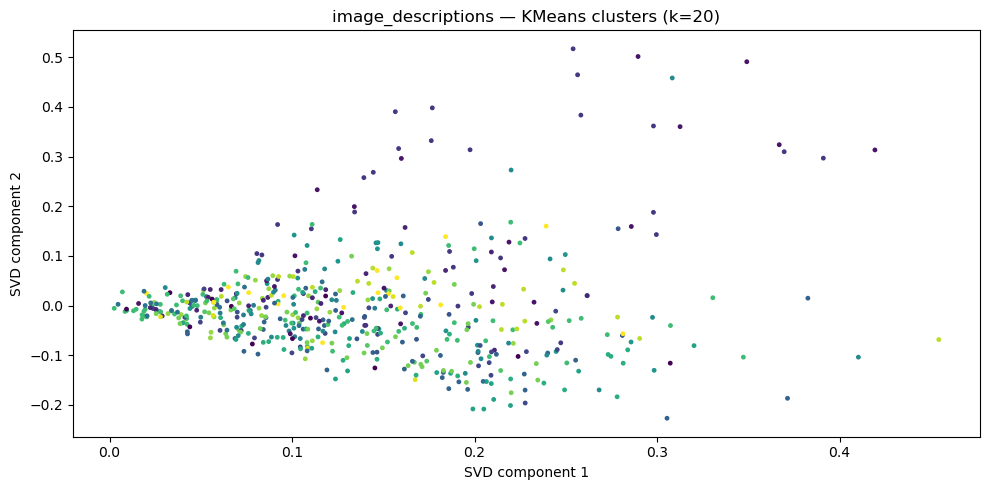


=== image_uncanny_descriptions — KMeans(k=20) top terms per cluster ===
Cluster 00: alive, looking, gingerbread, chefs, hospital, man, doctors, trees, smiling, beast
Cluster 01: people, middle, water, car, build, dog, shouldn, outside, thing, normally
Cluster 02: usually, standing, shark, humans, don, person, stand, close, upright, dragons
Cluster 03: giant, does, lizard, belong, paper, insects, unusual, enormous, sun, donut
Cluster 04: men, dozen, tiny, tubas, possible, bathroom, elevator, look, lay, watching
Cluster 05: earth, pinata, angels, aliens, communicating, carries, globe, playing, lot, oxygen
Cluster 06: large, unusual, lady, halo, balls, aren, unusually, beach, compared, satan
Cluster 07: man, head, mountain, like, lion, cannonballing, pool, piano, looks, diving
Cluster 08: place, really, office, stands, ufos, traps, image, sword, picture, anchor
Cluster 09: modern, woman, times, knight, kitchen, caveman, man, carrying, supposed, mosquitoes
Cluster 10: table, subway, stati

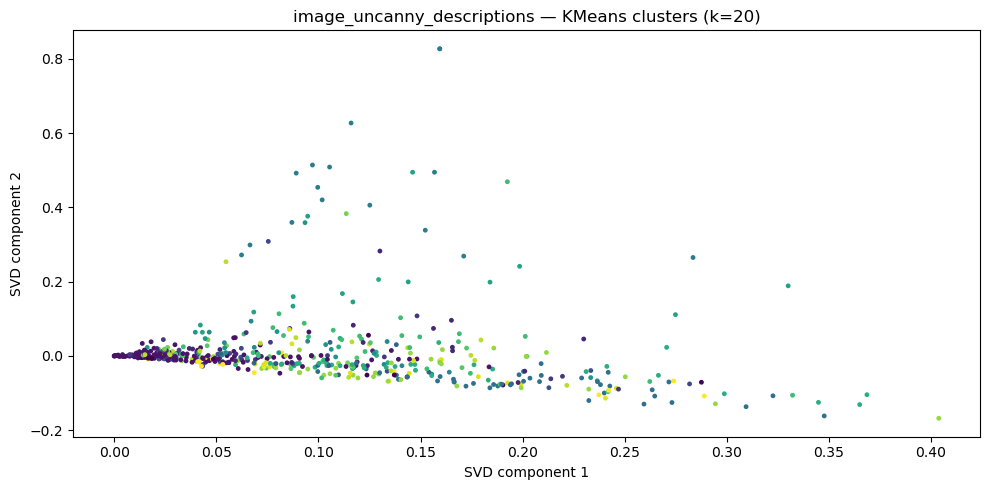


=== image_locations — KMeans(k=20) top terms per cluster ===
Cluster 00: bar, funeral, hard, hamster, hall, ground, grocery, graveyard, golf, gas
Cluster 01: field, party, forest, castle, ship, meeting, yard, sea, beach, kingdom
Cluster 02: cave, dwelling, yoga, gallery, hard, hamster, hall, ground, grocery, graveyard
Cluster 03: restaurant, yoga, funeral, hamster, hall, ground, grocery, graveyard, golf, gas
Cluster 04: room, living, forest, hamster, hall, ground, grocery, graveyard, golf, gas
Cluster 05: desert, middle, funeral, hard, hamster, hall, ground, grocery, graveyard, golf
Cluster 06: backyard, yoga, funeral, hard, hamster, hall, ground, grocery, graveyard, golf
Cluster 07: building, ledge, office, yoga, funeral, hamster, hall, ground, grocery, graveyard
Cluster 08: sidewalk, yoga, forest, hamster, hall, ground, grocery, graveyard, golf, gas
Cluster 09: park, bench, public, heaven, hard, hamster, hall, ground, grocery, graveyard
Cluster 10: subway, train, station, yoga, hard

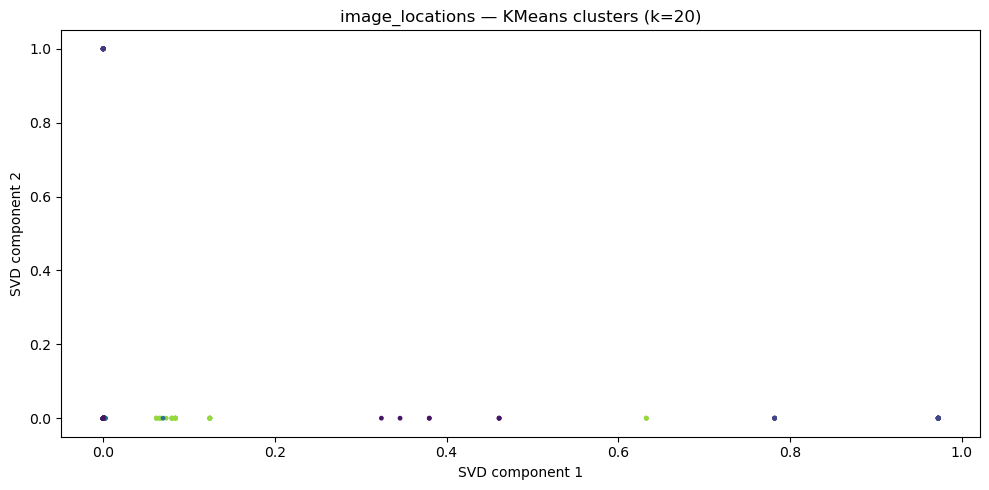


=== questions — KMeans(k=20) top terms per cluster ===
Cluster 00: built, washing, machines, tracks, house, stacked, pair, look, apartment, like
Cluster 01: cowboy, saying, far, falling, fall, faces, face, fable, explorer, explain
Cluster 02: using, office, sword, holding, man, desk, computers, person, embedded, ivs
Cluster 03: big, snail, city, hornets, menu, sword, waiter, head, attacking, gigantic
Cluster 04: wearing, like, dressed, person, dog, armor, horse, suit, propeller, woman
Cluster 05: going, king, color, doctor, building, bear, men, whale, caveman, cooking
Cluster 06: trying, room, living, baseball, hit, playing, hatch, row, man, slanted
Cluster 07: man, gingerbread, head, isn, mountain, dead, happy, cat, small, sandbox
Cluster 08: does, head, say, want, blender, long, man, hair, need, face
Cluster 09: saying, man, woman, caveman, waiter, employee, turtle, hiker, genie, horse
Cluster 10: angry, sheep, lizard, plaque, wolves, fish, experiment, fall, faces, face
Cluster 11: 

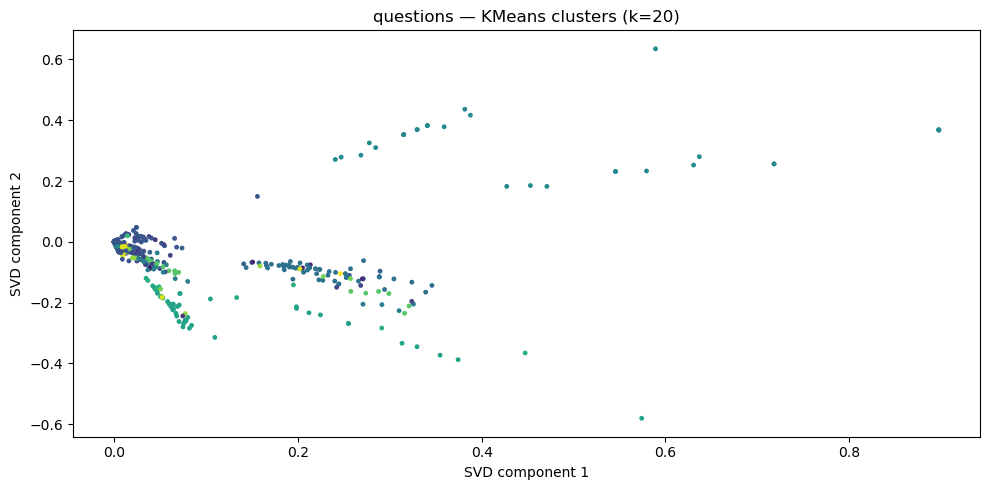

In [ ]:
import json, pathlib
from typing import List, Tuple
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD

# --- Config ---
PATH = pathlib.Path("data/newyorker_caption_contest/contests.json")
FIELDS = ["image_descriptions", "image_uncanny_descriptions", "image_locations", "questions"]
MAX_FEATURES = 5000
DEFAULT_NUM_CLUSTERS = 20
MIN_DOCS_FOR_CLUSTERING = 10      # skip clustering if fewer docs than this
TOP_TERMS_PER_CLUSTER = 10        # how many top words to show per cluster
RANDOM_STATE = 42

# --- Load & normalize JSON ---
def load_records(path: pathlib.Path):
    txt = path.read_text(encoding="utf-8")
    try:
        obj = json.loads(txt)
    except json.JSONDecodeError:
        recs = []
        with path.open(encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if line:
                    recs.append(json.loads(line))
        return recs
    if isinstance(obj, list):
        return obj
    if isinstance(obj, dict):
        if "contests" in obj and isinstance(obj["contests"], list):
            return obj["contests"]
        return [obj]
    raise ValueError("Unsupported JSON structure")

def collect_texts(records, field: str) -> List[str]:
    out = []
    for r in records:
        m = r.get("metadata") or {}
        v = m.get(field) if isinstance(m, dict) else None
        if isinstance(v, list):
            out.extend([s for s in v if isinstance(s, str)])
        elif isinstance(v, str):
            out.append(v)
    # basic cleanup: strip; drop empty
    out = [t.strip() for t in out if isinstance(t, str) and t.strip()]
    return out

def fit_tfidf(texts: List[str]) -> Tuple[TfidfVectorizer, np.ndarray]:
    vec = TfidfVectorizer(
        stop_words="english",
        max_features=MAX_FEATURES,
        token_pattern=r"(?u)\b[a-zA-Z]{3,}\b",  # words with >=3 letters
    )
    X = vec.fit_transform(texts)  # sparse matrix
    return vec, X

def auto_num_clusters(n_docs: int) -> int:
    # heuristic: up to DEFAULT_NUM_CLUSTERS, but never more than n_docs//5 and at least 2
    k = min(DEFAULT_NUM_CLUSTERS, max(2, n_docs // 5))
    return min(k, n_docs) if n_docs >= 2 else 0

def top_terms_per_cluster(kmeans: KMeans, vectorizer: TfidfVectorizer, top_n: int = 10):
    # approximate interpretability: use cluster centers to pick top-weighted features
    terms = vectorizer.get_feature_names_out()
    centers = kmeans.cluster_centers_
    for i, c in enumerate(centers):
        top_idx = np.argsort(c)[::-1][:top_n]
        yield i, [terms[j] for j in top_idx]

def plot_clusters_2d(X_sparse, labels, title: str):
    svd = TruncatedSVD(n_components=2, random_state=RANDOM_STATE)
    X_2d = svd.fit_transform(X_sparse)  # works on sparse
    plt.figure(figsize=(10, 5))
    plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, s=6, cmap="viridis")
    plt.title(title)
    plt.xlabel("SVD component 1")
    plt.ylabel("SVD component 2")
    plt.tight_layout()
    plt.show()

# --- Run per field ---
records = load_records(PATH)

for field in FIELDS:
    texts = collect_texts(records, field)
    n_docs = len(texts)
    if n_docs < MIN_DOCS_FOR_CLUSTERING:
        print(f"[{field}] Not enough documents ({n_docs}) — skipping clustering.")
        continue

    vectorizer, X_tfidf = fit_tfidf(texts)
    k = auto_num_clusters(n_docs)
    if k < 2:
        print(f"[{field}] Not enough documents for clustering — skipping.")
        continue

    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    kmeans.fit(X_tfidf)
    labels = kmeans.labels_

    # Print top terms per cluster (interpretation)
    print(f"\n=== {field} — KMeans(k={k}) top terms per cluster ===")
    for cid, terms in top_terms_per_cluster(kmeans, vectorizer, TOP_TERMS_PER_CLUSTER):
        print(f"Cluster {cid:02d}: {', '.join(terms)}")

    # Plot 2D clusters
    plot_clusters_2d(X_tfidf, labels, f"{field} — KMeans clusters (k={k})")


## Extract google trend data from march 2016 to september 2023

In [54]:
# === Google Trends for ALL tokens from your four CSVs ===
from pytrends.request import TrendReq
import pandas as pd
import numpy as np
from pathlib import Path
import time

# ---------- CONFIG ----------
CSV_DIR = Path("data/GoogleTrends/frequent_words")
FIELD_PREFIXES = [
    "image_descriptions",
    "image_uncanny_descriptions",
    "image_locations",
    "questions",
]
# We'll read ANY CSV that starts with one of the prefixes (so works with both nltk/non-nltk filenames)
TIMEFRAME = "2016-03-01 2023-09-30"   # March 2016 → September 2023
GEO = "US"                            # set "" for worldwide
BATCH_SIZE = 5                        # Google Trends limit per request
SLEEP_SEC = 2.0                       # politeness delay between calls
RETRY = 2                             # retry per batch on transient errors
MIN_TOKEN_LEN = 3                     # ignore ultra-short tokens
SAVE_PATH = Path("data/GoogleTrends/google_trends_ALL_tokens_2016_03_to_2023_09_US.csv")
# ----------------------------

def read_tokens_from_csvs(csv_dir: Path, prefixes):
    tokens = []
    for pref in prefixes:
        for p in csv_dir.glob(f"{pref}__*.csv"):
            df = pd.read_csv(p)
            if "token" not in df.columns:
                continue
            toks = (
                df["token"]
                .astype(str)
                .map(str.strip)
                .replace("", np.nan)
                .dropna()
                .tolist()
            )
            tokens.extend(toks)
    # de-duplicate preserving order; enforce min length
    seen = set()
    result = []
    for t in tokens:
        t_low = t.lower()
        if len(t_low) >= MIN_TOKEN_LEN and t_low not in seen:
            seen.add(t_low)
            result.append(t)
    return result

def chunks(lst, n):
    for i in range(0, len(lst), n):
        yield lst[i : i + n]

# 1) Collect ALL tokens
keywords = read_tokens_from_csvs(CSV_DIR, FIELD_PREFIXES)
if not keywords:
    raise ValueError(f"No tokens found in {CSV_DIR} for prefixes {FIELD_PREFIXES}")

print(f"Total unique keywords to fetch: {len(keywords)}")

# 2) Query Google Trends in batches (≤5)
pytrends = TrendReq(hl="en-US", tz=360)
frames = []
failed_batches = []

for batch in chunks(keywords, BATCH_SIZE):
    ok = False
    err = None
    for attempt in range(1, RETRY + 2):  # first try + retries
        try:
            pytrends.build_payload(kw_list=batch, timeframe=TIMEFRAME, geo=GEO)
            df = pytrends.interest_over_time()
            if "isPartial" in df.columns:
                df = df.drop(columns=["isPartial"])
            frames.append(df)
            ok = True
            break
        except Exception as e:
            err = e
            time.sleep(SLEEP_SEC * attempt)  # exponential-ish backoff
    if not ok:
        failed_batches.append((batch, repr(err)))
    time.sleep(SLEEP_SEC)

# 3) Merge results
if not frames:
    raise RuntimeError("No data returned from Google Trends. (All batches failed.)")

trends_wide = frames[0]
for df in frames[1:]:
    trends_wide = trends_wide.join(df, how="outer")

# Sort by date and fill missing with 0 (optional)
trends_wide = trends_wide.sort_index().fillna(0).astype(int)

# 4) Save single CSV (one column per keyword)
SAVE_PATH.parent.mkdir(parents=True, exist_ok=True)
trends_wide.to_csv(SAVE_PATH)
print(f"Saved trends to: {SAVE_PATH.resolve()}  with shape {trends_wide.shape}")

# 5) Minimal report on failures (if any)
if failed_batches:
    print("\nSome batches failed (columns missing for these keywords):")
    for batch, e in failed_batches:
        print(f"- {batch} -> {e}")

# 6) Quick sanity peek (first 5 columns & rows)
display(trends_wide.iloc[:5, :5])


Total unique keywords to fetch: 2263


KeyboardInterrupt: 

In [55]:
import pandas as pd
from pathlib import Path

# --- Config ---
INPUT_WIDE_CSV = Path("data/GoogleTrends/google_trends_ALL_tokens_2016_03_to_2023_09_US.csv")  # adjust if needed
OUTPUT_MEANS_CSV = Path("data/GoogleTrends/google_trends_means_2016_03_to_2023_09_US.csv")

# Use existing trends_wide if present; else load from CSV
if "trends_wide" in globals():
    df = trends_wide.copy()
else:
    # First column is the date index in the saved file
    df = pd.read_csv(INPUT_WIDE_CSV, index_col=0, parse_dates=True)

# Keep only numeric columns (keywords)
num = df.select_dtypes(include="number")

# Compute mean interest per keyword across the full timeframe
means = num.mean(axis=0, skipna=True)

# In case of any accidental duplicate column names, average them
means = means.groupby(level=0).mean()

# Build tidy result and sort
out = (
    means.reset_index()
         .rename(columns={"index": "token", 0: "mean_interest"})
         .sort_values("mean_interest", ascending=False)
         .reset_index(drop=True)
)

out["mean_interest"] = out["mean_interest"].round(3)

# Save
OUTPUT_MEANS_CSV.parent.mkdir(parents=True, exist_ok=True)
out.to_csv(OUTPUT_MEANS_CSV, index=False)


## Analysis of google trends data vs our data ##

Why do we talk more about men than women in captions, and does that reflect societal attention patterns seen on Google Trends?

Loaded 2263 unique tokens from your dataset.
Trends shape (time x tokens): (91, 2258)

=== Focus groups: dataset counts and ratios ===
- man: 558 (tokens: ['man', 'men'])
- woman: 158 (tokens: ['woman', 'women'])
Ratio man/woman: 3.53

Representative tokens found in Trends: {'man': 'man', 'woman': 'woman'}


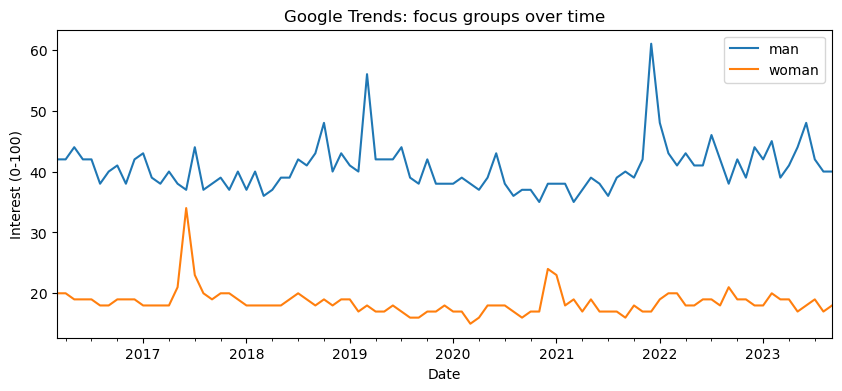


Correlation (ALL TOKENS): Pearson=0.097, Spearman=0.181


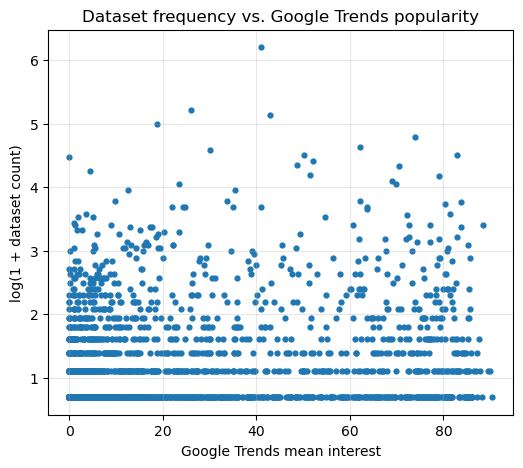


Ordering check (dataset vs. Trends):
- Dataset: man=558 vs woman=158  => a>b
- Trends : man=40.59 vs woman=18.52 => a>b

Time-shape agreement (z-scored): Pearson=-0.037, Kendall tau=0.125


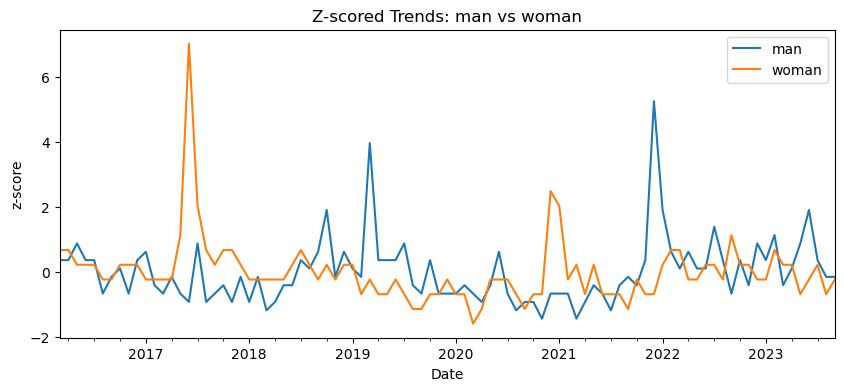

In [56]:
FREQ_FILES = [
    "data/GoogleTrends/frequent_words/image_descriptions__unigrams_nltk.csv",
    "data/GoogleTrends/frequent_words/image_locations__unigrams_nltk.csv",
    "data/GoogleTrends/frequent_words/image_uncanny_descriptions__unigrams_nltk.csv",
    "data/GoogleTrends/frequent_words/questions__unigrams_nltk.csv",
]


TRENDS_WIDE = "data/GoogleTrends/google_trends_ALL_tokens_2016_03_to_2023_09_US.csv"
TRENDS_MEANS = "data/GoogleTrends/google_trends_means_2016_03_to_2023_09_US.csv"

# focus groups
FOCUS_GROUPS = {
    "man": ["man", "men"],
    "woman": ["woman", "women"],
}

def load_frequencies(freq_files):
    """Load multiple unigram CSVs and sum counts across files """
    frames = []
    for f in freq_files:
        df = pd.read_csv(f)
        if "token" not in df.columns or "count" not in df.columns:
            raise ValueError(f"{f} must have columns: token,count")
        frames.append(df[["token", "count"]].copy())
    big = pd.concat(frames, ignore_index=True)
    big["token"] = big["token"].astype(str)
    agg = big.groupby("token", as_index=False)["count"].sum().sort_values("count", ascending=False)
    return agg

def group_count(freq_df, words):
    """Sum counts for a list of words (focus_groups)."""
    words = [w.lower() for w in words]
    sub = freq_df[freq_df["token"].str.lower().isin(words)]
    return int(sub["count"].sum())

def best_trends_token(trends_df, candidates):
    """ picks the first word from the group that actually exists in the Trends data."""
    for t in candidates:
        if t in trends_df.columns:
            return t
    return None

def zscore_df(df):
    """Z-score columns independently (drop all-NaN columns)."""
    df = df.copy()
    df = df.dropna(axis=1, how="all")
    scaler = StandardScaler(with_mean=True, with_std=True)
    arr = scaler.fit_transform(df.fillna(0.0))
    return pd.DataFrame(arr, index=df.index, columns=df.columns)


freq = load_frequencies(FREQ_FILES)
print(f"Loaded {len(freq)} unique tokens from your dataset.")

trends_wide = pd.read_csv(TRENDS_WIDE, index_col=0, parse_dates=True)
print(f"Trends shape (time x tokens): {trends_wide.shape}")

# Means per token. Otherwise compute from wide:
try:
    trends_means = pd.read_csv(TRENDS_MEANS)
    if not {"token", "mean_interest"}.issubset(trends_means.columns):
        raise ValueError("means file missing required columns")
    trends_means = trends_means[["token", "mean_interest"]].copy()
except Exception:
    # compute if not present
    cols_numeric = trends_wide.select_dtypes(include="number").columns
    trends_means = (
        trends_wide[cols_numeric]
        .mean(axis=0)
        .rename("mean_interest")
        .reset_index()
        .rename(columns={"index": "token"})
    )


print("\n=== Focus groups: dataset counts and ratios ===")
group_counts = {}
for group_name, variants in FOCUS_GROUPS.items():
    c = group_count(freq, variants)
    group_counts[group_name] = c
    print(f"- {group_name}: {c} (tokens: {variants})")

# compute ratio A/B
if len(group_counts) == 2:
    k = list(group_counts.keys())
    a, b = k[0], k[1]
    ra = group_counts[a]
    rb = group_counts[b]
    ratio = (ra / rb) if rb else np.nan
    print(f"Ratio {a}/{b}: {ratio:.2f}")

# Choose one representative token per group that actually exists in trends_wide
rep_tokens = {}
for g, variants in FOCUS_GROUPS.items():
    tok = best_trends_token(trends_wide, variants)
    if tok is not None:
        rep_tokens[g] = tok

if rep_tokens:
    print("\nRepresentative tokens found in Trends:", rep_tokens)
    ax = trends_wide[list(rep_tokens.values())].plot(figsize=(10,4), title="Google Trends: focus groups over time")
    ax.set_xlabel("Date")
    ax.set_ylabel("Interest (0-100)")
    plt.show()
else:
    print("\nNo representative tokens from your focus groups were found in the Trends table.")


# Merge per-token dataset counts with mean Trends interest
merged = freq.merge(trends_means, on="token", how="inner")
merged = merged[merged["mean_interest"].notna()].copy()

# Overall correlations across ALL tokens 
if len(merged) >= 3:
    pear = pearsonr(merged["count"], merged["mean_interest"])[0]
    spear = spearmanr(merged["count"], merged["mean_interest"]).correlation
    print(f"\nCorrelation (ALL TOKENS): Pearson={pear:.3f}, Spearman={spear:.3f}")
else:
    print("\nNot enough tokens overlap between dataset and Trends to compute overall correlation.")

# Scatter plot (log-scale counts to avoid domination by extreme words)
if len(merged) >= 3:
    plt.figure(figsize=(6,5))
    plt.scatter(merged["mean_interest"], np.log1p(merged["count"]), s=12)
    plt.xlabel("Google Trends mean interest")
    plt.ylabel("log(1 + dataset count)")
    plt.title("Dataset frequency vs. Google Trends popularity")
    plt.grid(True, alpha=0.3)
    plt.show()


# If you have exactly 2 groups, check whether ordering agrees: dataset vs trends
if len(FOCUS_GROUPS) == 2 and rep_tokens:
    # dataset ordering
    k = list(FOCUS_GROUPS.keys())
    a, b = k[0], k[1]
    count_a = group_counts.get(a, 0)
    count_b = group_counts.get(b, 0)
    ds_order = np.sign(count_a - count_b)  # +1 if a>b, -1 if a<b, 0 if tie

    # trends ordering using MEAN interest of representative tokens 
    ta = rep_tokens.get(a, None)
    tb = rep_tokens.get(b, None)
    if ta and tb:
        trend_a = trends_wide[ta].mean()
        trend_b = trends_wide[tb].mean()
        tr_order = np.sign(trend_a - trend_b)
        print(f"\nOrdering check (dataset vs. Trends):")
        print(f"- Dataset: {a}={count_a} vs {b}={count_b}  => {'a>b' if ds_order>0 else 'a<b' if ds_order<0 else 'tie'}")
        print(f"- Trends : {a}={trend_a:.2f} vs {b}={trend_b:.2f} => {'a>b' if tr_order>0 else 'a<b' if tr_order<0 else 'tie'}")
    else:
        print("\nCannot compute ordering: representative tokens missing in Trends.")


# correlation between the two time series
if len(rep_tokens) >= 2:
    sub = trends_wide[list(rep_tokens.values())].copy()
    sub_z = zscore_df(sub)   # normalize each series
    if sub_z.shape[1] == 2:
        a_col, b_col = sub_z.columns.tolist()
        pair = sub_z[[a_col, b_col]].dropna()
        tau = kendalltau(pair[a_col], pair[b_col]).correlation
        pear_t = pearsonr(pair[a_col], pair[b_col])[0]
        print(f"\nTime-shape agreement (z-scored): Pearson={pear_t:.3f}, Kendall tau={tau:.3f}")
        pair.plot(figsize=(10,4), title=f"Z-scored Trends: {a_col} vs {b_col}")
        plt.xlabel("Date"); plt.ylabel("z-score"); plt.show()


The pearson correlation is 0.094 which is very close to 0. This mean that there is no strong linear link between dataset frequency and Google Trends interest.
The pearman correlation is 0.174 which means a weak positive tendency. Some of the words that appear more often in the dataset are slightly more popular on Google, but not consistently.
This indicates that the vocabulary used in our dataset does not strongly reflect general public interest.
The dataset therefore captures a specific linguistic or cultural focus, rather than mirroring general online attention.

The scatter plot shows no strong linear pattern between dataset frequency and Google Trends popularity.
Words that are frequent in our corpus are not consistently popular in Google searches.

Are emotionally negative words (fear, death) more frequent during years with global crises (e.g., pandemic)?
Do location words (“New York”, “Paris”) correlate with spikes in Google Trends for those places?

Negative words found: ['fear', 'death', 'sad', 'worry', 'pain', 'suffering', 'panic', 'nervous']
Pandemic words found: ['distance']


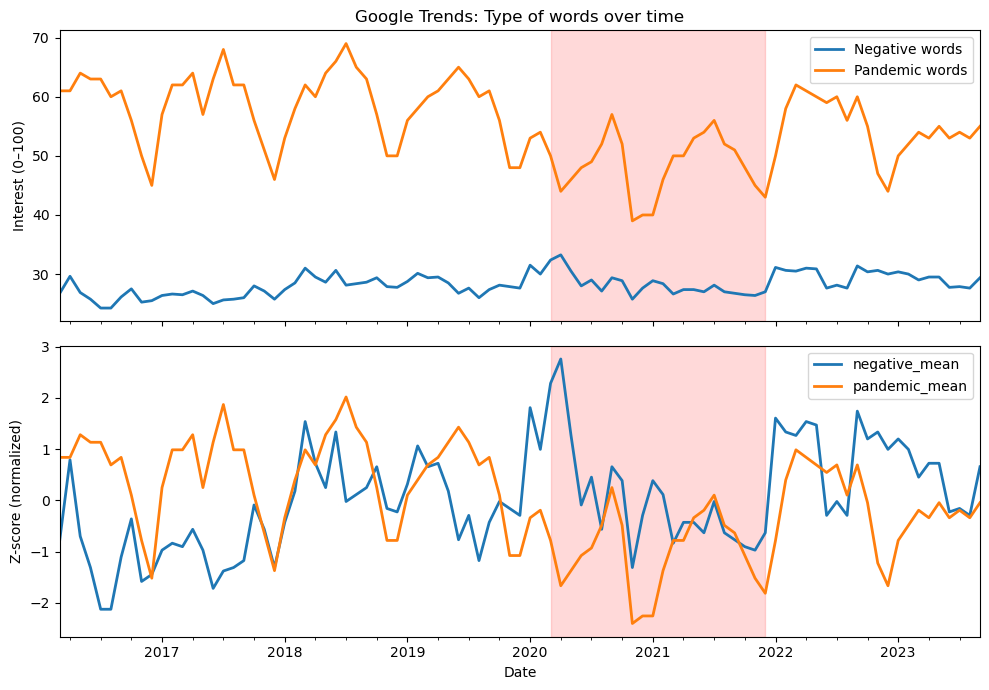


Average interest levels:


,pre_covid,covid,post_covid
negative_mean,27.5625,28.147727,29.565476
pandemic_mean,58.6875,48.409091,54.809524


In [79]:

trends = pd.read_csv("data/GoogleTrends/google_trends_ALL_tokens_2016_03_to_2023_09_US.csv", index_col=0, parse_dates=True)

NEGATIVE_WORDS = ["fear", "death", "anxiety", "sad", "worry", "crisis", "anger", "pain", "stress", "hate", "war", "depression", "trauma", "suffering", "loss", "grief", "panic", "nervous", "frustration", "helplessness"]
PANDEMIC_WORDS = ["pandemic", "virus", "covid", "quarantine", "lockdown", "vaccine", "mask", "social", "isolation", "outbreak", "immunity", "testing", "symptoms", "healthcare", "hygiene", "sanitizer", "ventilator", "distance","immunity"]

neg_available = [w for w in NEGATIVE_WORDS if w in trends.columns]
pand_available = [w for w in PANDEMIC_WORDS if w in trends.columns]

print("Negative words found:", neg_available)
print("Pandemic words found:", pand_available)

# average interest for each group over time
group_series = pd.DataFrame(index=trends.index)
group_series["negative_mean"] = trends[neg_available].mean(axis=1)
group_series["pandemic_mean"] = trends[pand_available].mean(axis=1)

# Optional: z-score normalize to highlight relative changes
scaler = StandardScaler()
group_series_z = pd.DataFrame(scaler.fit_transform(group_series), columns=group_series.columns, index=group_series.index)

# Plot raw and normalized series
fig, ax = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# (1) Raw means
group_series.plot(ax=ax[0], title="Google Trends: Type of words over time", linewidth=2)
ax[0].set_ylabel("Interest (0–100)")
ax[0].legend(["Negative words", "Pandemic words"])
ax[0].axvspan("2020-03", "2021-12", color="red", alpha=0.15, label="Pandemic period")

# (2) Z-scored (to compare shapes)
group_series_z.plot(ax=ax[1], linewidth=2)
ax[1].set_ylabel("Z-score (normalized)")
ax[1].axvspan("2020-03", "2021-12", color="red", alpha=0.15)
ax[1].set_xlabel("Date")

plt.tight_layout()
plt.show()

# Quantitative summary: compare mean interest before/during/after pandemic
pre_covid = group_series.loc["2016-03":"2020-02"].mean()
covid = group_series.loc["2020-03":"2021-12"].mean()
post_covid = group_series.loc["2022-01":"2023-09"].mean()

summary = pd.DataFrame({"pre_covid": pre_covid, "covid": covid, "post_covid": post_covid})
print("\nAverage interest levels:")
display(summary)


('fear', 'death', 'anxiety', 'sad', 'worry', 'crisis', 'anger', 'pain', 'stress', 'hate', 'war', 'depression', 'trauma', 'suffering', 'loss', 'grief', 'panic', 'nervous', 'frustration', 'helplessness'): [('2016-04', 2), ('2016-05', 1), ('2016-10', 4), ('2017-01', 1), ('2017-03', 3), ('2017-12', 3)] ...
('pandemic', 'virus', 'covid', 'quarantine', 'lockdown', 'vaccine', 'mask', 'social', 'isolation', 'outbreak', 'immunity', 'testing', 'symptoms', 'healthcare', 'hygiene', 'sanitizer', 'ventilator', 'immunity', 'distance'): [('2016-07', 1), ('2017-03', 1), ('2019-01', 1), ('2020-01', 1), ('2020-02', 1), ('2020-08', 1)] ...


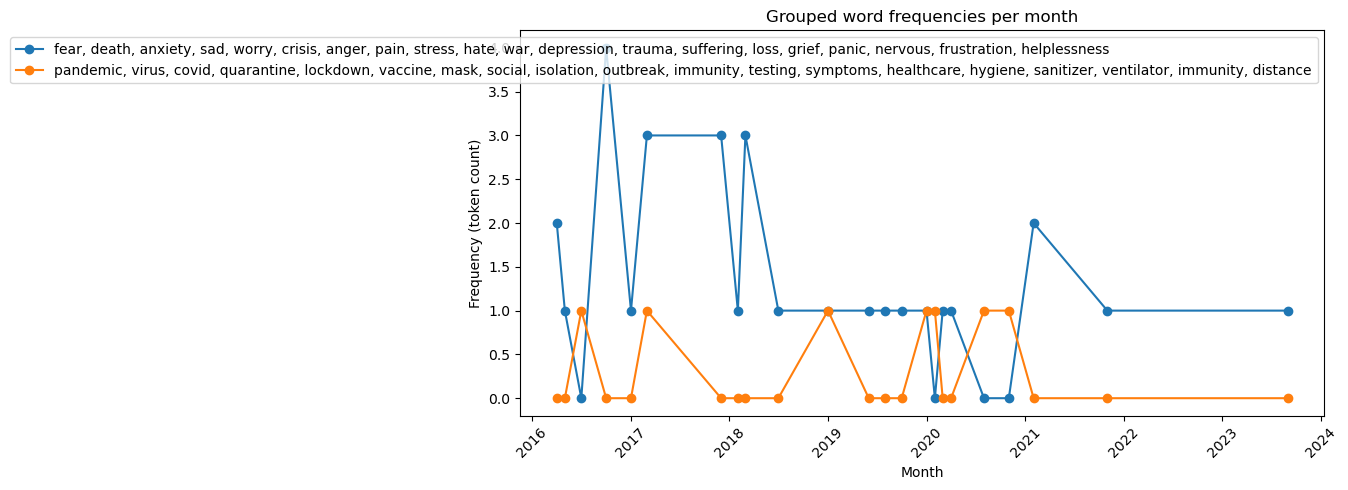

In [104]:
CSV_PATH = "data/newyorker_caption_contest/df_complete.csv"
DATE_COL = "date"
TEXT_COLS = [
    "image_locations",
    "image_descriptions",
    "image_uncanny_descriptions",
    "questions",
    "Top Rated caption",
]

# Your word groups. Each tuple is a dict key.
word_groups = [
    ("fear", "death", "anxiety", "sad", "worry", "crisis", "anger", "pain", "stress", "hate", "war", "depression", "trauma", "suffering", "loss", "grief", "panic", "nervous", "frustration", "helplessness"),
    ("pandemic", "virus", "covid", "quarantine", "lockdown", "vaccine", "mask", "social", "isolation", "outbreak", "immunity", "testing", "symptoms", "healthcare", "hygiene", "sanitizer", "ventilator","immunity", "distance"),
]

USE_LEMMA = True
try:
    from nltk.stem import WordNetLemmatizer
    import nltk
    nltk.download("wordnet", quiet=True)
    nltk.download("omw-1.4", quiet=True)
    LEMMA = WordNetLemmatizer()
except Exception:
    USE_LEMMA = False
    LEMMA = None


_word_re = re.compile(r"[a-z]+")  # only a-z tokens

def normalize_token(t: str) -> str:
    t = t.lower()
    if USE_LEMMA and LEMMA:
        t = LEMMA.lemmatize(t)
    return t

def tokenize_text(text) -> list[str]:
    if not isinstance(text, str) or not text:
        return []
    return [normalize_token(m.group(0)) for m in _word_re.finditer(text.lower())]

# wonthly frequencies per group
def build_group_month_frequencies(df: pd.DataFrame,
                                  text_cols=TEXT_COLS,
                                  groups=word_groups,
                                  date_col=DATE_COL) -> dict[tuple, dict[str, int]]:
    """
    Returns: {('w1','w2',...): {'YYYY-MM': count, ...}, ...}
    """
    # ensure columns exist
    missing = [c for c in text_cols + [date_col] if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in df: {missing}")

    # month as pandas Period 'M'
    months = pd.to_datetime(df[date_col], errors="coerce").dt.to_period("M")

    # map token -> groups containing it
    token_to_groups = defaultdict(set)
    for grp in groups:
        for w in grp:
            token_to_groups[normalize_token(w)].add(grp)

    # counts
    result: dict[tuple, defaultdict[str, int]] = {
        grp: defaultdict(int) for grp in groups
    }

    for i, row in df.iterrows():
        m = months.iat[i]
        if pd.isna(m):
            continue
        m_key = str(m)  # 'YYYY-MM'

        tokens: list[str] = []
        for col in text_cols:
            tokens.extend(tokenize_text(row[col]))
        counts = Counter(tokens)

        for tok, c in counts.items():
            if tok in token_to_groups and c > 0:
                for grp in token_to_groups[tok]:
                    result[grp][m_key] += c

    # sort inner dicts by month
    def sort_month_dict(d: dict[str, int]) -> dict[str, int]:
        # convert keys back to Period for sorting
        items = sorted(d.items(), key=lambda kv: pd.Period(kv[0], freq="M"))
        return dict(items)

    final = {grp: sort_month_dict(months_dict) for grp, months_dict in result.items()}
    return final


if __name__ == "__main__":
    # 1) Load CSV
    if not os.path.exists(CSV_PATH):
        raise FileNotFoundError(f"CSV not found: {CSV_PATH}")
    df_complete = pd.read_csv(CSV_PATH)

    # 2) Build nested dict (monthly)
    group_month_freq = build_group_month_frequencies(df_complete)

    for grp, md in group_month_freq.items():
        print(f"{grp}: {list(md.items())[:6]} ...")  # first few months

    # 3) Plot (monthly timeline)
    # Collect all months appearing in any group
    all_month_strs = sorted(
        {m for d in group_month_freq.values() for m in d.keys()},
        key=lambda s: pd.Period(s, freq="M"),
    )
    if not all_month_strs:
        print("No dated tokens found for the given groups.")
    else:
        # convert to timestamps for plotting
        x_periods = [pd.Period(s, freq="M") for s in all_month_strs]
        x_dates = [p.to_timestamp() for p in x_periods]

        plt.figure(figsize=(9, 5))
        for grp, mdict in group_month_freq.items():
            y_vals = [mdict.get(s, 0) for s in all_month_strs]
            plt.plot(x_dates, y_vals, marker="o", label=", ".join(grp))

        plt.xlabel("Month")
        plt.ylabel("Frequency (token count)")
        plt.title("Grouped word frequencies per month")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.legend()
        plt.show()




Batches:   0%|          | 0/9 [00:00<?, ?it/s]


=== dark_humor ===
graveyard, funeral, cemetery, coffin, corpses, coffins, death, killing, reaper, die

=== wordplay_puns ===


=== sarcasm_irony ===


=== absurd_surreal ===
ufo, centaur, centaurs, ufos, mythical, aliens, unicorn, unicorns, alien

=== topical_political ===


=== relationship_family ===
couple, marrying

=== workplace_office ===


=== animals ===
pets, animals, animal, cats, dogs, cat, barking, leash, lion, collar, dog, collars, bird, dolphin, horse


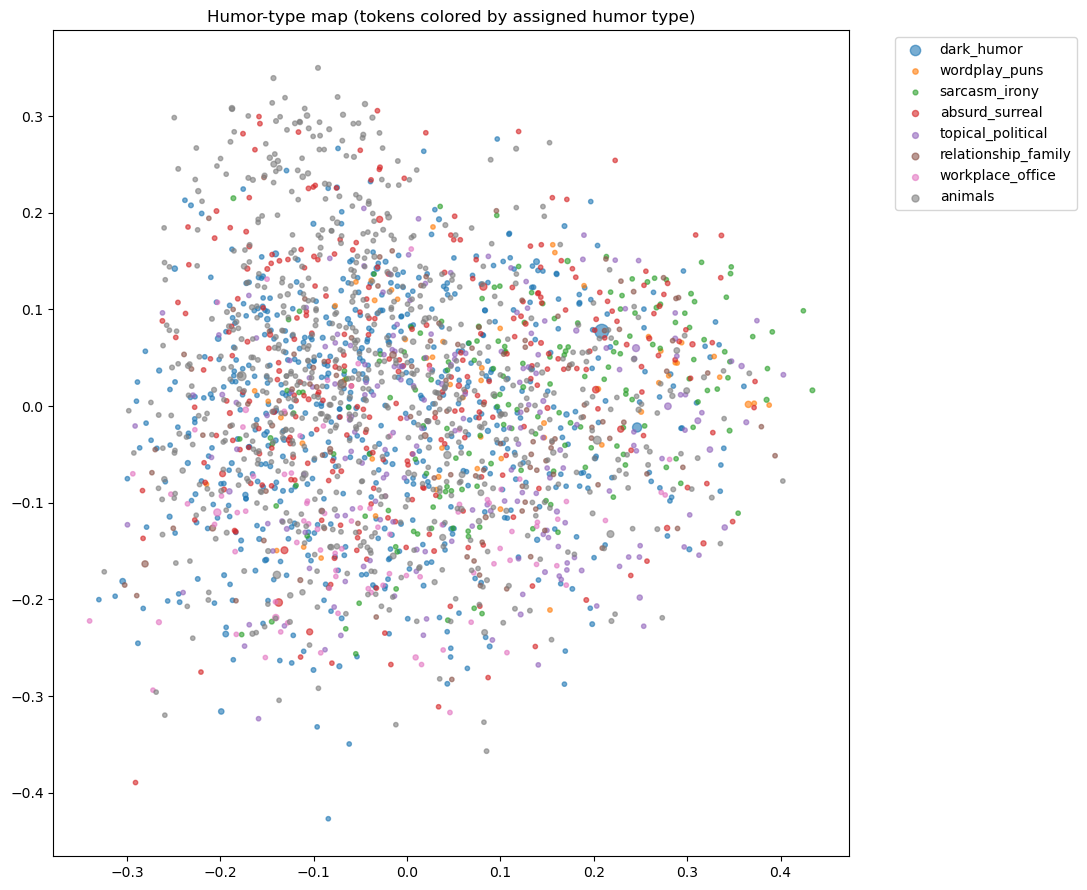


Done. Saved:
- data/humor_types/tokens_labeled_all.csv
- data/humor_types/tokens_labeled_confident.csv
- data/humor_types/lexicon_<type>.csv (per humor type)
- data/humor_types/humor_types_map.png (if PCA succeeded)


In [105]:
# humor_types_clustering

FILES = [
    "data/GoogleTrends/frequent_words/image_descriptions__unigrams_nltk.csv",
    "data/GoogleTrends/frequent_words/image_locations__unigrams_nltk.csv",
    "data/GoogleTrends/frequent_words/image_uncanny_descriptions__unigrams_nltk.csv",
    "data/GoogleTrends/frequent_words/questions__unigrams_nltk.csv",
]
dfs = [pd.read_csv(f) for f in FILES]
df = pd.concat(dfs, ignore_index=True)

df["token"] = df["token"].astype(str).str.lower().str.strip()
df = (df.groupby("token", as_index=False)["count"]
        .sum()
        .sort_values("count", ascending=False))
#filter 
df = df[df["token"].str.len() >= 3]


HUMOR_TYPES = {
    "dark_humor": [
        "death","dying","killer","grave","cemetery","coffin","suicide","grim","morbidity",
        "funeral","mourning","doom","bleak","apocalypse","disease","cancer","war","bomb"
    ],
    "wordplay_puns": [
        "pun","wordplay","double meaning","homophone","homonym","punny","dad joke","literal",
        "misunderstanding","twist","ambiguity","rhyme","alliteration"
    ],
    "sarcasm_irony": [
        "sarcasm","sarcastic","irony","ironic","deadpan","mock","snark","understatement",
        "overstatement","hyperbole","satire","sardonic"
    ],
    "absurd_surreal": [
        "absurd","surreal","nonsense","impossible","paradox","bizarre","weird","alien",
        "unicorn","centaur","talking animal","ufo","dreamlike","nonsensical"
    ],
    "topical_political": [
        "election","vote","president","campaign","trump","biden","senate","congress","policy",
        "covid","pandemic","mask","lockdown","vaccine","war","protest","economy","inflation"
    ],
    "relationship_family": [
        "marriage","wife","husband","boyfriend","girlfriend","date","relationship","family",
        "kids","parents","mother","father","valentine","romance","breakup","divorce"
    ],
    "workplace_office": [
        "office","meeting","boss","coworker","email","deadline","promotion","salary","zoom",
        "spreadsheet","presentation","desk","manager","client"
    ],
    "animals": [
        "dog","cat","bird","fish","horse","cow","duck","bear","monkey","elephant","zebra",
        "lion","tiger","pet","leash","vet","fur","bark","meow"
    ],
}


model = SentenceTransformer("all-MiniLM-L6-v2")

TOKEN_LIST = df["token"].tolist()
E_tokens = model.encode(TOKEN_LIST, batch_size=256, show_progress_bar=True)

type_names = list(HUMOR_TYPES.keys())
seed_texts = [" ".join(HUMOR_TYPES[t]) for t in type_names]  
E_types = model.encode(seed_texts, show_progress_bar=False)

S = cosine_similarity(E_tokens, E_types)

freq = df["count"].to_numpy()
freq_norm = (freq - freq.min()) / (freq.max() - freq.min() + 1e-9)

best_idx = S.argmax(axis=1)
df["humor_type"] = [type_names[i] for i in best_idx]
df["type_score"] = S.max(axis=1)

for i, t in enumerate(type_names):
    df[f"score_{t}"] = S[:, i]

MIN_SCORE = 0.40 
df_high = df[df["type_score"] >= MIN_SCORE].copy()


# Save labeled vocabulary for later use

out_dir = Path("data/humor_types")
out_dir.mkdir(parents=True, exist_ok=True)
df.to_csv(out_dir / "tokens_labeled_all.csv", index=False)
df_high.to_csv(out_dir / "tokens_labeled_confident.csv", index=False)

# Quick inspection: top words per humor type
def show_top_words(df_labelled, k=15):
    for t in type_names:
        sub = (df_labelled[df_labelled["humor_type"] == t]
               .sort_values(["type_score","count"], ascending=False)
               .head(k))
        print(f"\n=== {t} ===")
        print(", ".join(sub["token"].tolist()))

show_top_words(df_high, k=15)


try:
    X2 = PCA(n_components=2, random_state=42).fit_transform(E_tokens)
    df_vis = df.copy()
    df_vis["x"] = X2[:,0]
    df_vis["y"] = X2[:,1]

    plt.figure(figsize=(11,9))
    for t in type_names:
        m = df_vis["humor_type"] == t
        plt.scatter(
            df_vis.loc[m,"x"], df_vis.loc[m,"y"],
            s=10 + 90*freq_norm[m], alpha=0.6, label=t
        )
    plt.title("Humor-type map (tokens colored by assigned humor type)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(out_dir / "humor_types_map.png", dpi=200)
    plt.show()
except Exception as e:
    print("Plot skipped:", e)

for t in type_names:
    sub = df_high[df_high["humor_type"] == t][["token","count","type_score"]]
    sub.to_csv(out_dir / f"lexicon_{t}.csv", index=False)

print("\nDone. Saved:")
print("- data/humor_types/tokens_labeled_all.csv")
print("- data/humor_types/tokens_labeled_confident.csv")
print("- data/humor_types/lexicon_<type>.csv (per humor type)")
print("- data/humor_types/humor_types_map.png (if PCA succeeded)")


Humor types: ['absurd_surreal', 'animals', 'dark_humor']


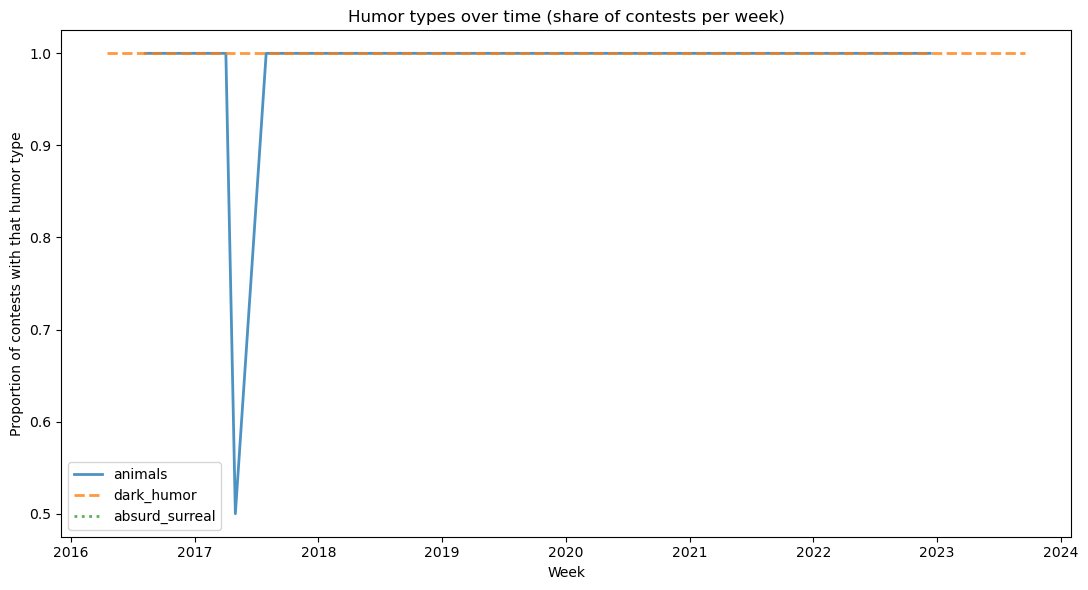

Saved: data/humor_types/weekly_humor_types_contest_level.csv


In [107]:

dfc = df_complete.copy()

# unify date column
date_col = "Date" if "Date" in dfc.columns else ("date" if "date" in dfc.columns else None)
if date_col is None:
    raise ValueError("No Date/date column found in df_complete.")
dfc["Date"] = pd.to_datetime(dfc[date_col], errors="coerce")

text_cols_str = [c for c in ["Top Rated caption", "The New Yorker's winner"] if c in dfc.columns]
text_cols_list = [c for c in ["image_descriptions","image_uncanny_descriptions","image_locations","entities","questions", "Top Rated caption"]
                  if c in dfc.columns]

def to_text(x):
    """Convert cell to a space-joined string."""
    if isinstance(x, (list, tuple)):
        return " ".join(str(t) for t in x if pd.notna(t))
    if pd.isna(x):
        return ""
    return str(x)

doc_parts = []
for col in text_cols_str + text_cols_list:
    doc_parts.append(dfc[col].apply(to_text) if col in dfc.columns else "")

# concatenated document per contest
dfc["doc"] = pd.Series([""] * len(dfc))
for part in doc_parts:
    dfc["doc"] = (dfc["doc"].astype(str) + " " + part.astype(str)).str.strip()

# Clean minimal (lowercase, keep letters/apostrophes/spaces)
dfc["doc"] = (dfc["doc"].str.lower()
                        .str.replace(r"[^a-z'\s]", " ", regex=True)
                        .str.replace(r"\s+", " ", regex=True)
                        .str.strip())


lex_path = Path("data/humor_types/tokens_labeled_confident.csv")
lex = pd.read_csv(lex_path)

# tighten lexicon (tune thresholds if needed)
if "type_score" in lex and "count" in lex:
    lex = lex[(lex["type_score"] >= 0.45) & (lex["count"] >= 5)].copy()

lex["token"] = lex["token"].astype(str).str.lower().str.strip()
type2tokens = (lex.groupby("humor_type")["token"]
                 .apply(lambda s: set(s.tolist()))
                 .to_dict())
humor_types = list(type2tokens.keys())
print("Humor types:", humor_types)

#  Tag contests: which humor types appear in each contest document?
token_re = re.compile(r"[a-z']+")

def doc_types(text: str):
    words = set(token_re.findall(text))
    hits = [t for t, toks in type2tokens.items() if len(words & toks) > 0]
    return hits

dfc["humor_types"] = dfc["doc"].apply(doc_types)

#  store a boolean indicator per type 
for t in humor_types:
    dfc[f"type__{t}"] = dfc["humor_types"].apply(lambda L: t in L)


#  Weekly time series (per-humor-type counts & proportions of contests)
dfc = dfc.dropna(subset=["Date"])
dfc["week"] = dfc["Date"].dt.to_period("W").apply(lambda p: p.start_time)

# explode to (contest, type) rows for counting
df_expl = dfc.explode("humor_types")
df_expl["humor_types"] = df_expl["humor_types"].fillna("unlabeled")

# per week per type: number of contests that include that type
week_counts = (df_expl.groupby(["week","humor_types"])
                        .size()
                        .rename("contests_with_type")
                        .reset_index())

# total contests per week (denominator for proportions)
week_totals = (dfc.groupby("week")["contest_id"]
                 .nunique()
                 .rename("total_contests")
                 .reset_index())

weekly = week_counts.merge(week_totals, on="week", how="left")
weekly["prop_contests"] = weekly["contests_with_type"] / weekly["total_contests"].replace(0, np.nan)

# Save tidy weekly table
out_dir = Path("data/humor_types")
out_dir.mkdir(parents=True, exist_ok=True)
weekly.to_csv(out_dir / "weekly_humor_types_contest_level.csv", index=False)


weekly_labeled = weekly[weekly["humor_types"]!="unlabeled"].copy()
top_types = (weekly_labeled.groupby("humor_types")["contests_with_type"]
                          .sum()
                          .sort_values(ascending=False)
                          .head(6).index.tolist())

plt.figure(figsize=(11,6))
linestyles = ['-', '--', ':', '-.']
for i, t in enumerate(top_types):
    sub = weekly_labeled[weekly_labeled["humor_types"] == t].sort_values("week")
    plt.plot(sub["week"], sub["prop_contests"], label=t,
             linewidth=2, alpha=0.8, linestyle=linestyles[i % len(linestyles)])

plt.title("Humor types over time (share of contests per week)")
plt.xlabel("Week")
plt.ylabel("Proportion of contests with that humor type")
plt.legend()
plt.tight_layout()
plt.show()

print("Saved:", out_dir / "weekly_humor_types_contest_level.csv")



# Word Frequency Analysis on Top 10 Captions per cartoon

## Extracting the Most Influential Words from the Top Captions

In [2]:
!pip install nltk

  Using cached nltk-3.9.2-py3-none-any.whl.metadata (3.2 kB)
Using cached nltk-3.9.2-py3-none-any.whl (1.5 MB)


In [3]:
import pathlib, csv, re
from collections import Counter, defaultdict
import nltk
from nltk.corpus import stopwords
try:
    from nltk.tokenize import word_tokenize
except Exception:
    word_tokenize = None

def _ensure_nltk():
    for pkg in ["stopwords", "punkt", "punkt_tab"]:
        try:
            if pkg == "stopwords":
                nltk.data.find(f"corpora/{pkg}")
            else:
                nltk.data.find(f"tokenizers/{pkg}")
        except LookupError:
            nltk.download(pkg, quiet=True)

_ensure_nltk()

from nltk.corpus import stopwords
try:
    from nltk.tokenize import word_tokenize as _wt
    word_tokenize = _wt
except Exception:
    pass

EN_STOP = set(stopwords.words("english"))

# ---- config ----
BASE    = pathlib.Path("data/newyorker_caption_contest")
CSV_DIR = BASE / "data"   # where 510.csv, 511.csv, ... live
OUTDIR  = pathlib.Path("data/GoogleTrends/frequent_words")

TOKEN_RE = re.compile(r"[A-Za-z]{3,}")

def tokenize_lower(text: str):
    if word_tokenize is not None:
        try:
            return [w.lower() for w in word_tokenize(text)]
        except LookupError:
            return [w.lower() for w in TOKEN_RE.findall(text)]
    else:
        return [w.lower() for w in TOKEN_RE.findall(text)]

def count_tokens_nltk(texts):
    c = Counter()
    for t in texts:
        tokens = tokenize_lower(t)
        filtered = [w for w in tokens if w.isalpha() and len(w) >= 3 and w not in EN_STOP]
        c.update(filtered)
    return c

# ---- aggregate per contest ----
global_counts = Counter()                       
per_contest_counts = defaultdict(Counter)       

for cid in range(510, 896):  # 510 to 895 inclusive
    path = CSV_DIR / f"{cid}.csv"
    if not path.exists():
        continue

    texts = []
    with path.open(encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for i, row in enumerate(reader):
            if i >= 10:
                break
            cap = row.get("caption", "")
            if isinstance(cap, str) and cap.strip():
                texts.append(cap)

    if not texts:
        continue

    contest_counts = count_tokens_nltk(texts)
    global_counts.update(contest_counts)
    for tok, freq in contest_counts.items():
        per_contest_counts[tok][cid] += freq

# ---- save: token, count, Id (best contest for each token) ----
OUTDIR.mkdir(parents=True, exist_ok=True)
out_path = OUTDIR / "captions_top10_unigrams_best_contest.csv"

with out_path.open("w", newline="", encoding="utf-8") as f:
    w = csv.writer(f)
    w.writerow(["token", "count", "Id"])
    for tok, contest_counter in per_contest_counts.items():
        if not contest_counter:
            continue
        # find contest where this token is most frequent
        top_cid, top_count = max(contest_counter.items(), key=lambda kv: kv[1])
        w.writerow([tok, top_count, top_cid])

print(f"Saved token + best contest stats -> {out_path}")

Saved token + best contest stats -> data/GoogleTrends/frequent_words/captions_top10_unigrams_best_contest.csv


## Same analysis as before but for the top 10 captions for each cartoon 


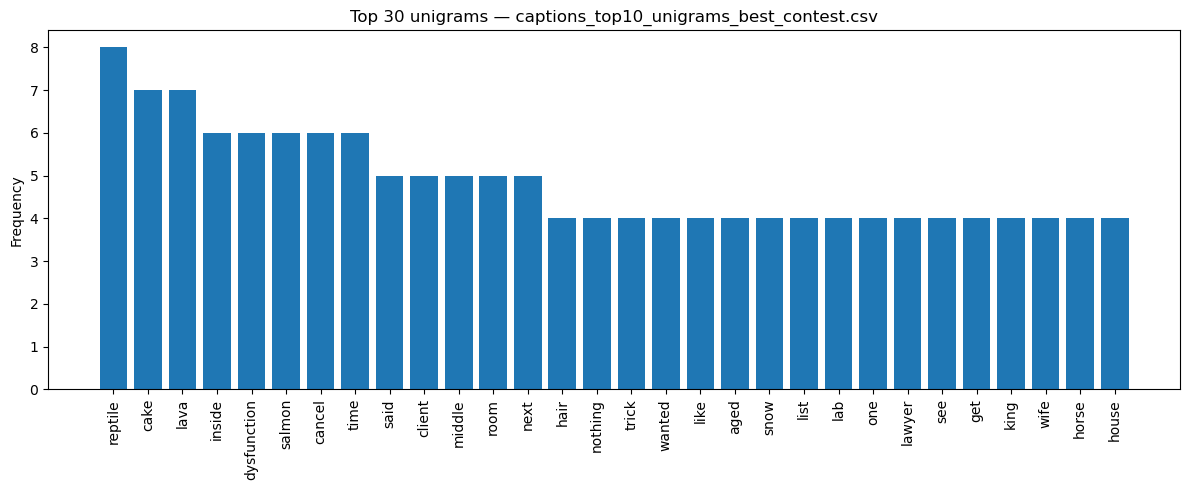

In [83]:
CSV_PATH = Path("data/GoogleTrends/frequent_words/captions_top10_unigrams_best_contest.csv")

df = pd.read_csv(CSV_PATH)

word_col = "token"      
count_col = "count"   

df_agg = (
    df.groupby(word_col, as_index=False)[count_col]
      .sum()
      .sort_values(count_col, ascending=False)
)


top_df = df_agg.head(TOP_K)

# Plot frequency of top unigrams
plt.figure(figsize=(12, 5))
plt.bar(top_df[word_col], top_df[count_col])
plt.xticks(rotation=90)
plt.title(f"Top {TOP_K} unigrams — captions_top10_unigrams_best_contest.csv")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

Loaded 4823 unique tokens from BEST-CONTEST dataset.
Trends shape (time x tokens): (91, 1315)

=== Focus groups: BEST-CONTEST dataset counts and ratios ===
- reptile: 8 (tokens: ['reptile'])
- cake: 7 (tokens: ['cake'])
- time: 6 (tokens: ['time'])

Representative tokens found in Trends: {'reptile': 'reptile', 'time': 'time'}


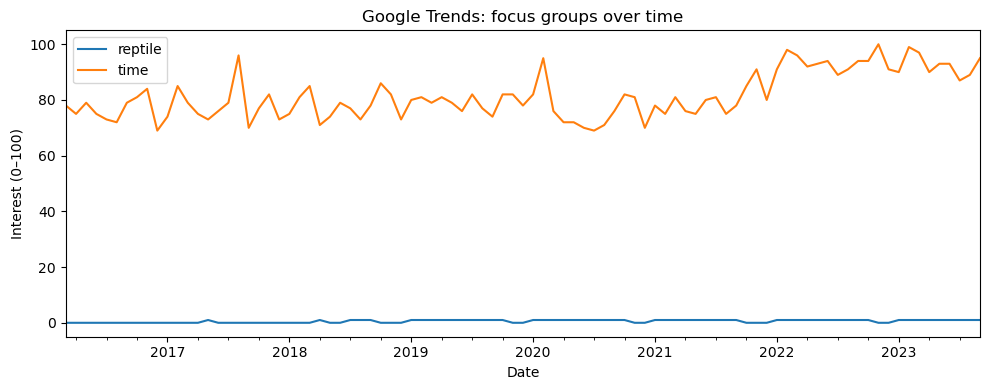


Overlapping tokens between BEST-CONTEST and Trends: 608
Correlation (ALL TOKENS): Pearson=0.162, Spearman=0.202


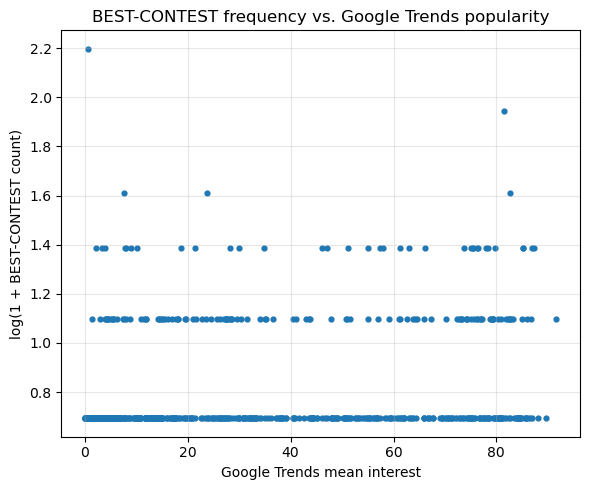


Time-shape agreement (z-scored Trends series): Pearson=0.200, Kendall tau=0.138


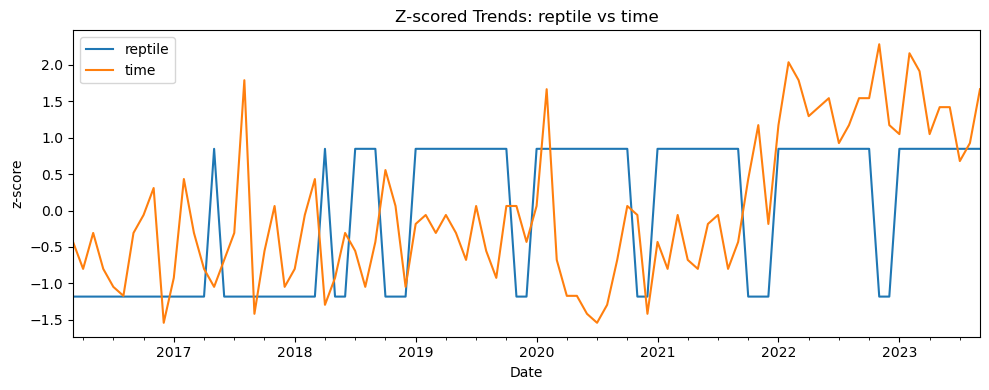

cake True False
pandemic True False
Trump False False
covid True False


In [ ]:

BEST_FREQ_FILE = "data/GoogleTrends/frequent_words/captions_top10_unigrams_best_contest.csv"

# Google Trends files
TRENDS_WIDE = "data/GoogleTrends/google_trends_ALL_tokens_2016_03_to_2023_09_US.csv"
TRENDS_MEANS = "data/GoogleTrends/google_trends_means_2016_03_to_2023_09_US.csv"

# Focus groups
FOCUS_GROUPS = {
   # "man": ["man", "men"],
   # "woman": ["woman", "women"],
    "reptile": ["reptile"],
    "cake": ["cake"], 
    "time" : ["time"]
}


# 1) Frequencies from BEST-CONTEST captions
freq = load_frequencies([BEST_FREQ_FILE])
print(f"Loaded {len(freq)} unique tokens from BEST-CONTEST dataset.")


# 2) Google Trends
trends_wide = pd.read_csv(TRENDS_WIDE, index_col=0, parse_dates=True)
print(f"Trends shape (time x tokens): {trends_wide.shape}")

# 3) Per-token mean interest (precomputed or computed here)
try:
    trends_means = pd.read_csv(TRENDS_MEANS)
    if not {"token", "mean_interest"}.issubset(trends_means.columns):
        raise ValueError("means file missing required columns")
    trends_means = trends_means[["token", "mean_interest"]].copy()
except Exception:
    print("Could not use precomputed means, computing from wide table...")
    cols_numeric = trends_wide.select_dtypes(include="number").columns
    trends_means = (
        trends_wide[cols_numeric]
        .mean(axis=0)
        .rename("mean_interest")
        .reset_index()
        .rename(columns={"index": "token"})
    )



print("\n=== Focus groups: BEST-CONTEST dataset counts and ratios ===")
group_counts = {}
for group_name, variants in FOCUS_GROUPS.items():
    c = group_count(freq, variants)
    group_counts[group_name] = c
    print(f"- {group_name}: {c} (tokens: {variants})")

# ratio A/B if exactly two groups
if len(group_counts) == 2:
    k = list(group_counts.keys())
    a, b = k[0], k[1]
    ra = group_counts[a]
    rb = group_counts[b]
    ratio = (ra / rb) if rb else np.nan
    print(f"Ratio {a}/{b}: {ratio:.2f}")

# Choose one representative token per group that exists in trends_wide
rep_tokens = {}
for g, variants in FOCUS_GROUPS.items():
    tok = best_trends_token(trends_wide, variants)
    if tok is not None:
        rep_tokens[g] = tok

if rep_tokens:
    print("\nRepresentative tokens found in Trends:", rep_tokens)
    ax = trends_wide[list(rep_tokens.values())].plot(
        figsize=(10, 4),
        title="Google Trends: focus groups over time"
    )
    ax.set_xlabel("Date")
    ax.set_ylabel("Interest (0–100)")
    plt.tight_layout()
    plt.show()
else:
    print("\nNo representative tokens from your focus groups were found in the Trends table.")



# Merge BEST-CONTEST counts with mean Trends interest per token
merged = freq.merge(trends_means, on="token", how="inner")
merged = merged[merged["mean_interest"].notna()].copy()
print(f"\nOverlapping tokens between BEST-CONTEST and Trends: {len(merged)}")

# Overall correlation across all overlapping tokens
if len(merged) >= 3:
    pear = pearsonr(merged["count"], merged["mean_interest"])[0]
    spear = spearmanr(merged["count"], merged["mean_interest"]).correlation
    print(f"Correlation (ALL TOKENS): Pearson={pear:.3f}, Spearman={spear:.3f}")
else:
    print("Not enough overlapping tokens to compute overall correlation.")

# Scatter plot: Trends popularity vs BEST-CONTEST frequency
if len(merged) >= 3:
    plt.figure(figsize=(6, 5))
    plt.scatter(merged["mean_interest"], np.log1p(merged["count"]), s=12)
    plt.xlabel("Google Trends mean interest")
    plt.ylabel("log(1 + BEST-CONTEST count)")
    plt.title("BEST-CONTEST frequency vs. Google Trends popularity")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()



if len(FOCUS_GROUPS) == 2 and rep_tokens:
    # dataset ordering
    k = list(FOCUS_GROUPS.keys())
    a, b = k[0], k[1]
    count_a = group_counts.get(a, 0)
    count_b = group_counts.get(b, 0)
    ds_order = np.sign(count_a - count_b)  # +1 if a>b, -1 if a<b, 0 if tie

    # trends ordering using mean interest of representative tokens
    ta = rep_tokens.get(a, None)
    tb = rep_tokens.get(b, None)
    if ta and tb:
        trend_a = trends_wide[ta].mean()
        trend_b = trends_wide[tb].mean()
        tr_order = np.sign(trend_a - trend_b)
        print(f"\nOrdering check (BEST-CONTEST vs. Trends):")
        print(f"- BEST-CONTEST: {a}={count_a} vs {b}={count_b}  "
              f"=> {'a>b' if ds_order>0 else 'a<b' if ds_order<0 else 'tie'}")
        print(f"- Trends      : {a}={trend_a:.2f} vs {b}={trend_b:.2f} "
              f"=> {'a>b' if tr_order>0 else 'a<b' if tr_order<0 else 'tie'}")
    else:
        print("\nCannot compute ordering: representative tokens missing in Trends.")


if len(rep_tokens) >= 2:
    sub = trends_wide[list(rep_tokens.values())].copy()
    sub_z = zscore_df(sub)   # normalize each series
    if sub_z.shape[1] == 2:
        a_col, b_col = sub_z.columns.tolist()
        pair = sub_z[[a_col, b_col]].dropna()
        tau = kendalltau(pair[a_col], pair[b_col]).correlation
        pear_t = pearsonr(pair[a_col], pair[b_col])[0]
        print(f"\nTime-shape agreement (z-scored Trends series): "
              f"Pearson={pear_t:.3f}, Kendall tau={tau:.3f}")
        pair.plot(figsize=(10, 4), title=f"Z-scored Trends: {a_col} vs {b_col}")
        plt.xlabel("Date")
        plt.ylabel("z-score")
        plt.tight_layout()
        plt.show()

for w in ["cake", "pandemic", "Trump", "covid"]:
    print(w, w in freq["token"].values, w in trends_wide.columns)


Batches:   0%|          | 0/19 [00:00<?, ?it/s]


=== dark_humor ===
grave, funeral, death, dies, dying, buried, killers, suicide, reaper, die, coroner, murder, requiem, apocalypse, kills

=== wordplay_puns ===


=== sarcasm_irony ===
irony, sarcastic, mocking, sarcasm

=== absurd_surreal ===
aliens, unicorn, unicorns, alien

=== topical_political ===
pandemic, vaccine, vaccination, covid, trumpcare, vaccinated, presidential

=== relationship_family ===
divorce, divorced, marriage, affair, couples, couple, marrying

=== workplace_office ===


=== animals ===
animals, animal, vet, pet, cats, dogcatfish, beagle, dogs, cat, barking, leash, dog, geese, bark, puppies


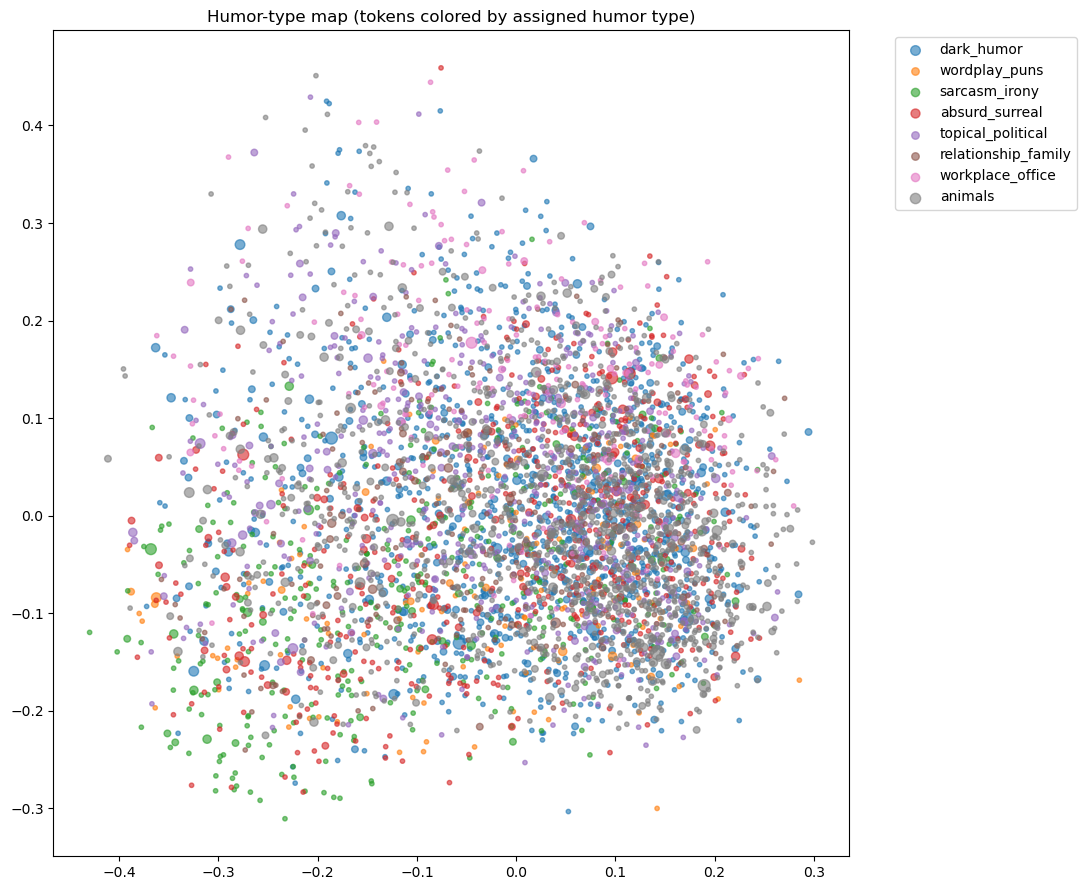


Done. Saved:
- data/humor_types/tokens_labeled_all.csv
- data/humor_types/tokens_labeled_confident.csv
- data/humor_types/lexicon_<type>.csv (per humor type)
- data/humor_types/humor_types_map.png (if PCA succeeded)


In [96]:
# humor_types_clustering

FILES = ["data/GoogleTrends/frequent_words/captions_top10_unigrams_best_contest.csv"]
dfs = [pd.read_csv(f) for f in FILES]
df = pd.concat(dfs, ignore_index=True)

df["token"] = df["token"].astype(str).str.lower().str.strip()
df = (df.groupby("token", as_index=False)["count"]
        .sum()
        .sort_values("count", ascending=False))
#filter 
df = df[df["token"].str.len() >= 3]


HUMOR_TYPES = {
    "dark_humor": [
        "death","dying","killer","grave","cemetery","coffin","suicide","grim","morbidity",
        "funeral","mourning","doom","bleak","apocalypse","disease","cancer","war","bomb"
    ],
    "wordplay_puns": [
        "pun","wordplay","double meaning","homophone","homonym","punny","dad joke","literal",
        "misunderstanding","twist","ambiguity","rhyme","alliteration"
    ],
    "sarcasm_irony": [
        "sarcasm","sarcastic","irony","ironic","deadpan","mock","snark","understatement",
        "overstatement","hyperbole","satire","sardonic"
    ],
    "absurd_surreal": [
        "absurd","surreal","nonsense","impossible","paradox","bizarre","weird","alien",
        "unicorn","centaur","talking animal","ufo","dreamlike","nonsensical"
    ],
    "topical_political": [
        "election","vote","president","campaign","trump","biden","senate","congress","policy",
        "covid","pandemic","mask","lockdown","vaccine","war","protest","economy","inflation"
    ],
    "relationship_family": [
        "marriage","wife","husband","boyfriend","girlfriend","date","relationship","family",
        "kids","parents","mother","father","valentine","romance","breakup","divorce"
    ],
    "workplace_office": [
        "office","meeting","boss","coworker","email","deadline","promotion","salary","zoom",
        "spreadsheet","presentation","desk","manager","client"
    ],
    "animals": [
        "dog","cat","bird","fish","horse","cow","duck","bear","monkey","elephant","zebra",
        "lion","tiger","pet","leash","vet","fur","bark","meow"
    ],
}


model = SentenceTransformer("all-MiniLM-L6-v2")

TOKEN_LIST = df["token"].tolist()
E_tokens = model.encode(TOKEN_LIST, batch_size=256, show_progress_bar=True)

type_names = list(HUMOR_TYPES.keys())
seed_texts = [" ".join(HUMOR_TYPES[t]) for t in type_names]  
E_types = model.encode(seed_texts, show_progress_bar=False)

S = cosine_similarity(E_tokens, E_types)

freq = df["count"].to_numpy()
freq_norm = (freq - freq.min()) / (freq.max() - freq.min() + 1e-9)

best_idx = S.argmax(axis=1)
df["humor_type"] = [type_names[i] for i in best_idx]
df["type_score"] = S.max(axis=1)

for i, t in enumerate(type_names):
    df[f"score_{t}"] = S[:, i]

MIN_SCORE = 0.40 
df_high = df[df["type_score"] >= MIN_SCORE].copy()


# Save labeled vocabulary for later use

out_dir = Path("data/humor_types")
out_dir.mkdir(parents=True, exist_ok=True)
df.to_csv(out_dir / "tokens_labeled_all.csv", index=False)
df_high.to_csv(out_dir / "tokens_labeled_confident.csv", index=False)

# Quick inspection: top words per humor type
def show_top_words(df_labelled, k=15):
    for t in type_names:
        sub = (df_labelled[df_labelled["humor_type"] == t]
               .sort_values(["type_score","count"], ascending=False)
               .head(k))
        print(f"\n=== {t} ===")
        print(", ".join(sub["token"].tolist()))

show_top_words(df_high, k=15)


try:
    X2 = PCA(n_components=2, random_state=42).fit_transform(E_tokens)
    df_vis = df.copy()
    df_vis["x"] = X2[:,0]
    df_vis["y"] = X2[:,1]

    plt.figure(figsize=(11,9))
    for t in type_names:
        m = df_vis["humor_type"] == t
        plt.scatter(
            df_vis.loc[m,"x"], df_vis.loc[m,"y"],
            s=10 + 90*freq_norm[m], alpha=0.6, label=t
        )
    plt.title("Humor-type map (tokens colored by assigned humor type)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(out_dir / "humor_types_map.png", dpi=200)
    plt.show()
except Exception as e:
    print("Plot skipped:", e)

for t in type_names:
    sub = df_high[df_high["humor_type"] == t][["token","count","type_score"]]
    sub.to_csv(out_dir / f"lexicon_{t}.csv", index=False)

print("\nDone. Saved:")
print("- data/humor_types/tokens_labeled_all.csv")
print("- data/humor_types/tokens_labeled_confident.csv")
print("- data/humor_types/lexicon_<type>.csv (per humor type)")
print("- data/humor_types/humor_types_map.png (if PCA succeeded)")

Number of confident tokens used for classification: 48

Logistic regression accuracy:
- train accuracy: 0.947
- test  accuracy: 0.900

Classification report (on test set):
                precision    recall  f1-score   support

absurd_surreal      1.000     0.500     0.667         2
       animals      0.857     1.000     0.923         6
    dark_humor      1.000     1.000     1.000         2

      accuracy                          0.900        10
     macro avg      0.952     0.833     0.863        10
  weighted avg      0.914     0.900     0.887        10



/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


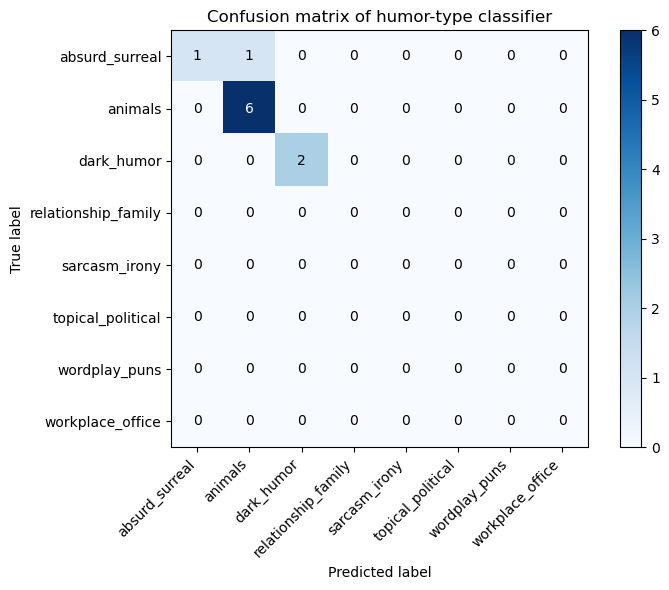

In [110]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np


# we use only confident tokens to avoid noisy labels
mask_high = df["type_score"] >= MIN_SCORE
X_emb = E_tokens[mask_high]                      
y = df.loc[mask_high, "humor_type"].to_numpy()        

print(f"Number of confident tokens used for classification: {X_emb.shape[0]}")

# train/test split with stratification to keep class balance
X_train, X_test, y_train, y_test = train_test_split(
    X_emb, y, test_size=0.2, random_state=42, stratify=y
)

#  Train logistic regression classifier 

clf = LogisticRegression(max_iter=2000, multi_class="auto")
clf.fit(X_train, y_train)

train_acc = clf.score(X_train, y_train)
test_acc = clf.score(X_test, y_test)
print(f"\nLogistic regression accuracy:")
print(f"- train accuracy: {train_acc:.3f}")
print(f"- test  accuracy: {test_acc:.3f}")


y_pred = clf.predict(X_test)
print("\nClassification report (on test set):")
print(classification_report(y_test, y_pred, digits=3))

# Confusion matrix 

labels_order = sorted(type_names)   # same order everywhere
cm = confusion_matrix(y_test, y_pred, labels=labels_order)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title("Confusion matrix of humor-type classifier")
plt.colorbar()
tick_marks = np.arange(len(labels_order))
plt.xticks(tick_marks, labels_order, rotation=45, ha="right")
plt.yticks(tick_marks, labels_order)

plt.ylabel("True label")
plt.xlabel("Predicted label")

# annotate cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() * 0.5 else "black")

plt.tight_layout()
plt.show()
